# Python and Business Analytics

## Data Science on Shopping Centre Customers

This notebook uses a synthetic dataset constructed in 2015 and available through Kaggle. There are 200 fictional customers and the dataset consists of 5 columns: Customer ID; Gender; Age; Annual Income (k$); Spending Score.

The data file is called: Kaggle_Mall_Customers.csv.

Clustering analysis, using age and income data, can be a powerful tool for market segmentation in retail.

In [1]:
# Import libraries/modules.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
# Reading the data.
df = pd.read_csv('Kaggle_Mall_Customers.csv')
df.head(3)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6


In [2]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


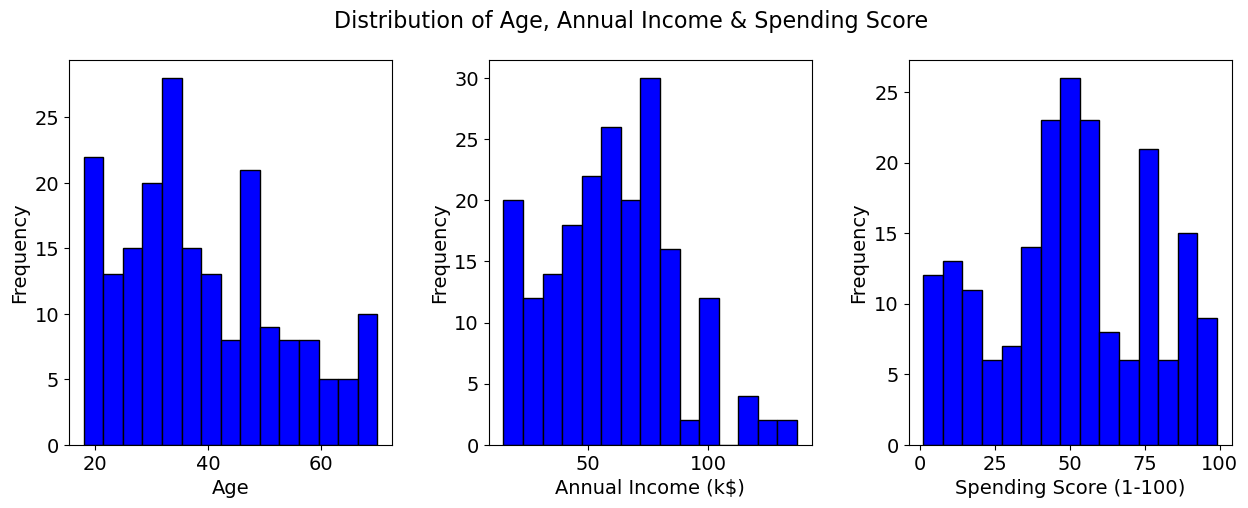

In [3]:
# Create Histograms.
plt.figure(figsize=(15, 5))
plt.rcParams["font.size"] = 14
for i, col in enumerate(['Age', 'Annual Income (k$)', 'Spending Score (1-100)']):
    plt.subplot(1, 3, i + 1)
    # Use matplotlib's hist without normalization
    plt.hist(df[col], bins=15, color='blue', edgecolor='black', density=False)  # Ensure density=False.
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.suptitle('Distribution of Age, Annual Income & Spending Score', fontsize=16)
plt.subplots_adjust(wspace=0.3)
plt.show()

<Figure size 1500x600 with 0 Axes>

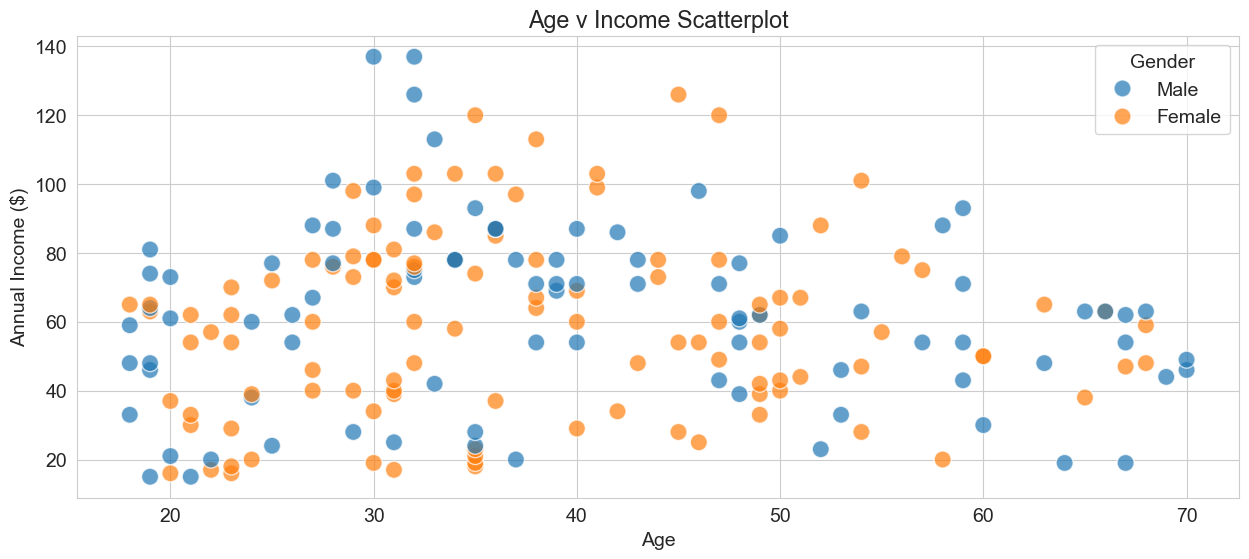

In [4]:
# Set style
sns.set_style('whitegrid')
plt.figure(figsize=(15, 6))
# Create Scatterplot
plt.figure(figsize=(15, 6))
sns.scatterplot(x='Age', y='Annual Income (k$)', data=df, hue='Gender', s=150, alpha=0.7)
plt.xlabel('Age')
plt.ylabel('Annual Income ($)')
plt.title('Age v Income Scatterplot')
plt.show()

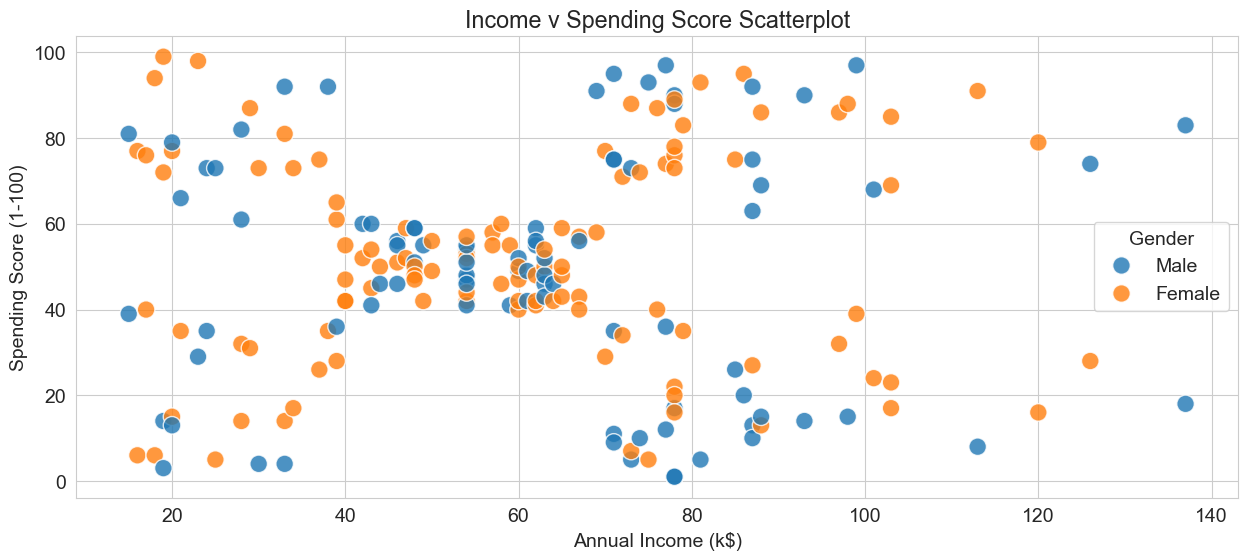

In [5]:
# Set style
sns.set_style('whitegrid')
plt.figure(figsize=(15, 6))
# Create scatter plot of Annual Income and Age, colored by Gender
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', hue='Gender',  s=160, alpha=0.8)
# Add title
plt.title('Income v Spending Score Scatterplot')
plt.show()

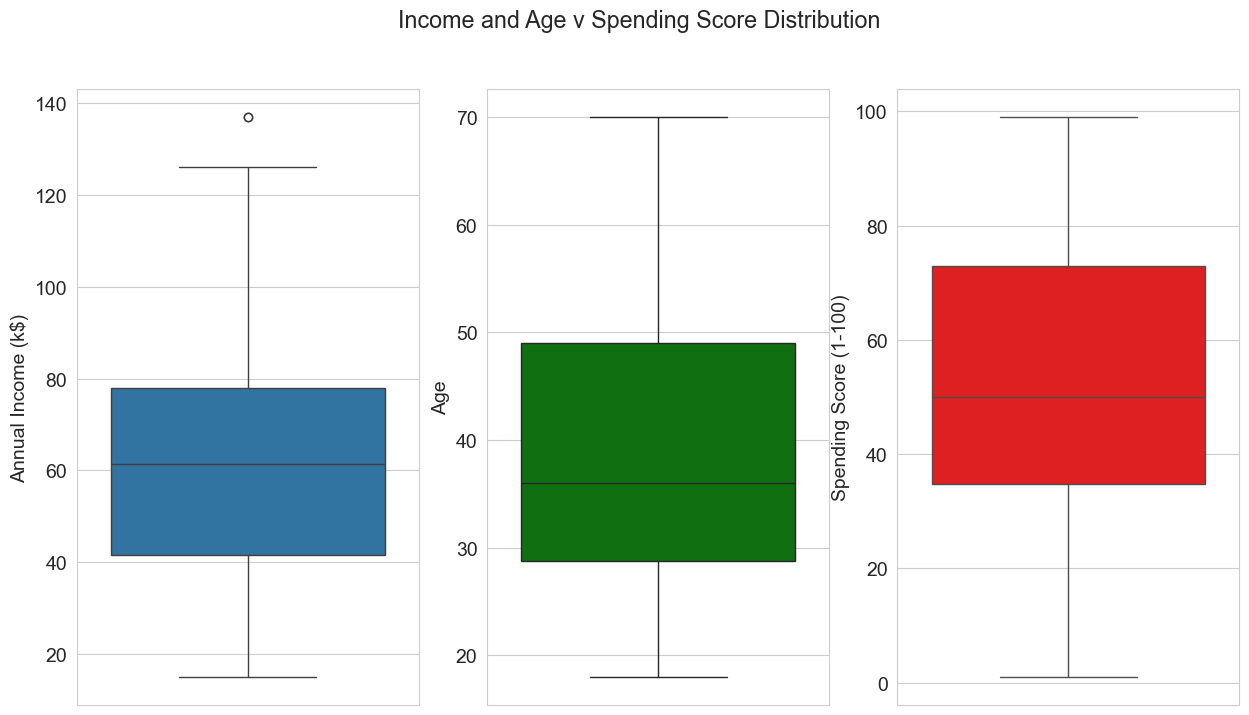

In [6]:
# Set style
sns.set_style('whitegrid')
plt.figure(figsize=(15, 8))
# Create box and whisker plots.
plt.subplot(1, 3, 1)
sns.boxplot(y=df["Annual Income (k$)"])
plt.subplot(1, 3, 2)
sns.boxplot(y=df["Age"], color='green')
plt.subplot(1, 3, 3)
sns.boxplot(y=df["Spending Score (1-100)"], color='red')
# Add title
plt.suptitle('Income and Age v Spending Score Distribution' , x = 0.5)
plt.show()

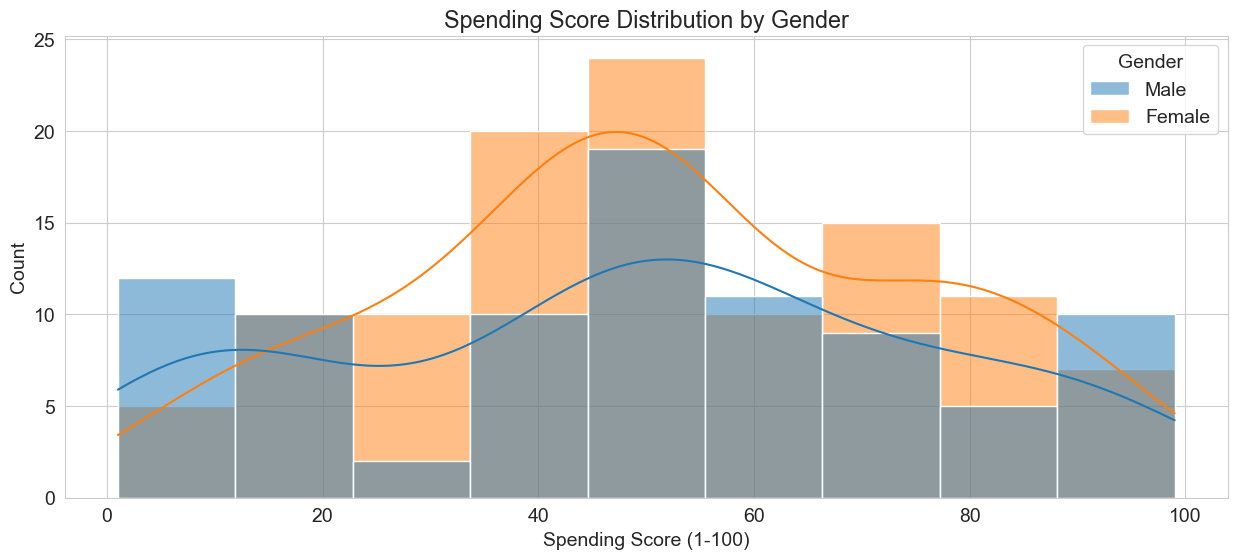

In [7]:
# Set style
sns.set_style('whitegrid')
plt.figure(figsize=(15, 6))
# Create Histogram
sns.histplot(data=df, x='Spending Score (1-100)', hue='Gender', kde=True)
# Add title
plt.title('Spending Score Distribution by Gender')
plt.show()

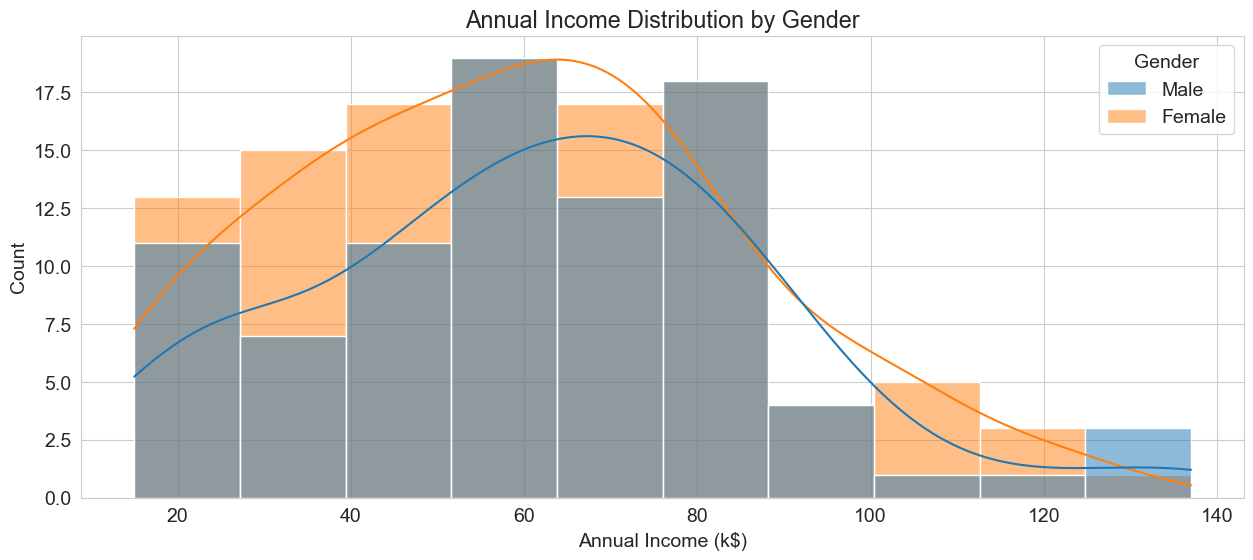

In [8]:
# Set style.
sns.set_style('whitegrid')
plt.figure(figsize=(15, 6))
# Create Histogram.
sns.histplot(data=df, x='Annual Income (k$)', hue='Gender', kde=True)
plt.title('Annual Income Distribution by Gender')
plt.show()

In [9]:
# Normalise data
from sklearn.preprocessing import MinMaxScaler
# Select numerical columns to normalize
num_cols = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
# Initialise scaler
scaler = MinMaxScaler()
# Normalise
df[num_cols] = scaler.fit_transform(df[num_cols])
df.head(3)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,0.019231,0.000000,0.387755
1,2,Male,0.057692,0.000000,0.816327
2,3,Female,0.038462,0.008197,0.051020


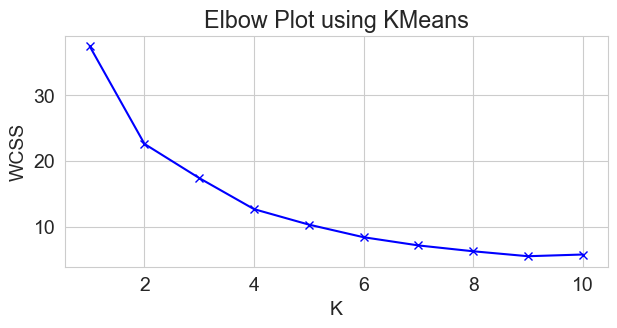

In [10]:
# Create empty lists for WCSS values & their respective K Values
from sklearn.cluster import KMeans
wcss_values = []
k_values = []
# Fit KMeans
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='random', random_state=42, n_init = 10)
    kmeans.fit(df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']])
    wcss_values.append(kmeans.inertia_)
    k_values.append(k)
# Plot Elbow plot
plt.figure(figsize=(7, 3))
plt.plot(k_values, wcss_values, 'bx-')
plt.xlabel('K')
plt.ylabel('WCSS')
plt.title('Elbow Plot using KMeans')
plt.show()

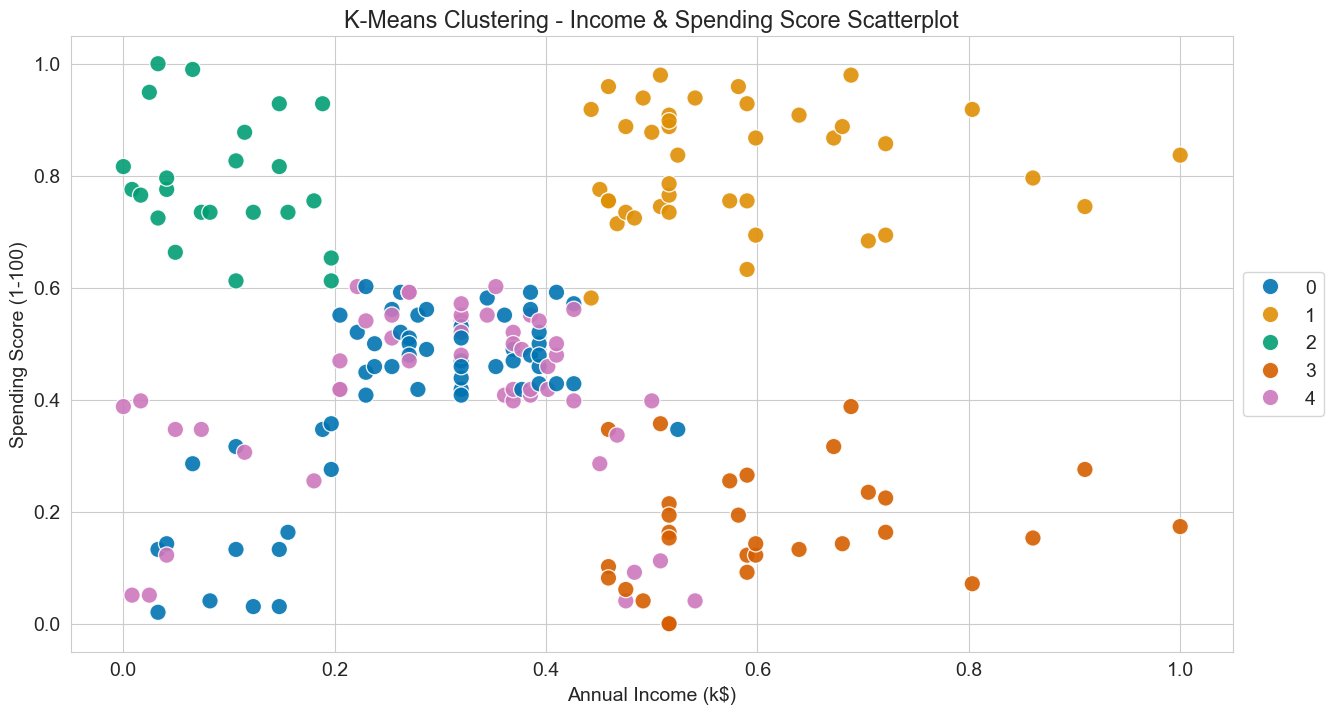

In [11]:
# Create k-means object - 5 clusters.
num_clusters = 5
kmeans = KMeans(n_clusters = num_clusters , n_init = 10)
# Fit k-means object to the data.
kmeans.fit(df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']])
# Add cluster labels to original df
df['Cluster'] = kmeans.labels_
# Set style & figure size.
sns.set_style('whitegrid')
plt.figure(figsize=(15, 8))
# Plot clusters.
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', data=df, hue='Cluster', palette='colorblind', alpha=0.9, s=140)
# Set title, axis labels & legend.
plt.title('K-Means Clustering - Income & Spending Score Scatterplot')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

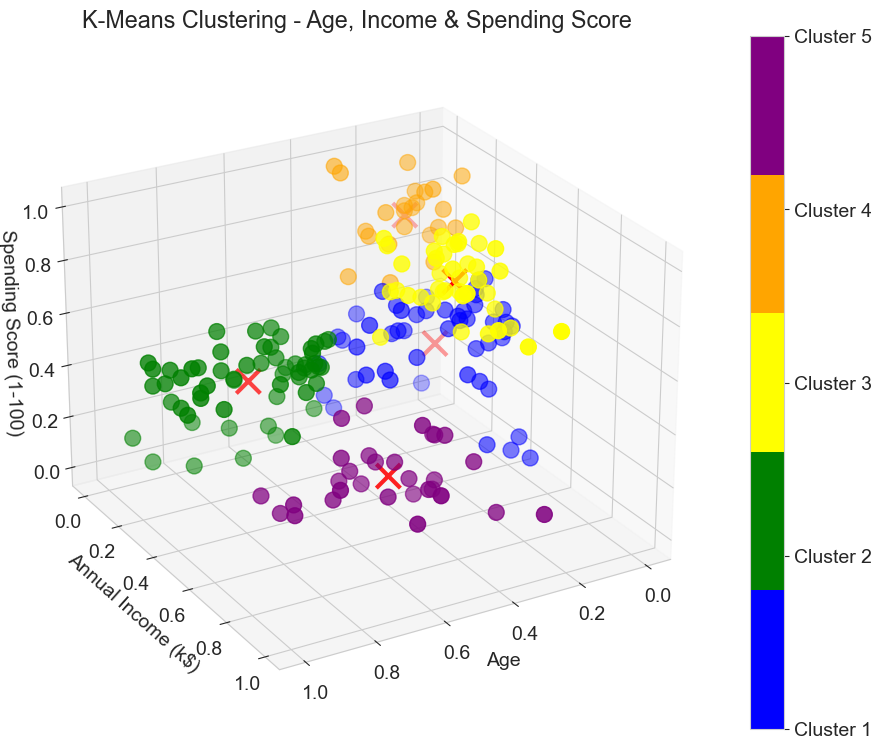

In [12]:
# Create k-means object - 5 clusters. Static plot.
"""
Run the notebook in JupyterLab to get an interactive 3D plot.
"""
# %matplotlib qt5
from matplotlib.colors import ListedColormap
kmeans = KMeans(n_clusters = num_clusters , n_init = 10)
# Fit k-means object to the data.
kmeans.fit(df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']])
# Add cluster labels to original df.
df['Cluster'] = kmeans.labels_
# Set style.
sns.set_style('whitegrid')
fig = plt.figure(figsize=(12, 9))
# Create custom colormap.
my_cmap = plt.colormaps['viridis']
# Create 3D scatter plot.
cluster_colors = ['blue', 'green', 'yellow', 'orange', 'purple']  # Choose your own colours.
my_cmap = ListedColormap(cluster_colors)
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(df['Age'], df['Annual Income (k$)'], df['Spending Score (1-100)'], c=df['Cluster'], s=130, cmap=my_cmap)
cbar = plt.colorbar(scatter)
cbar.set_ticks(np.arange(0, num_clusters))
cbar.set_ticklabels(['Cluster 1', 'Cluster 2', 'Cluster 3' , 'Cluster 4' , 'Cluster 5'])
# Set axis labels and title.
ax.set_xlabel('Age')
ax.set_ylabel('Annual Income (k$)')
ax.set_zlabel('Spending Score (1-100)')
ax.set_title('K-Means Clustering - Age, Income & Spending Score')
# Plot centroids
centroids = kmeans.cluster_centers_
ax.scatter(centroids[:, 0], centroids[:, 1], centroids[:, 2], marker='x', s=300, linewidths=3, color='red', zorder=10)
# Change the viewing angles.
ax.view_init(elev = 25, azim = 60)
plt.show()

In [13]:
# Calculate silhouette score - the closer to one the better!
# For this example, there are 5 clusters.
from sklearn.metrics import silhouette_samples, silhouette_score
silhouette_avg = silhouette_score(df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']], kmeans.labels_)
print("The average silhouette_score is :", silhouette_avg)

The average silhouette_score is : 0.40611743307078185


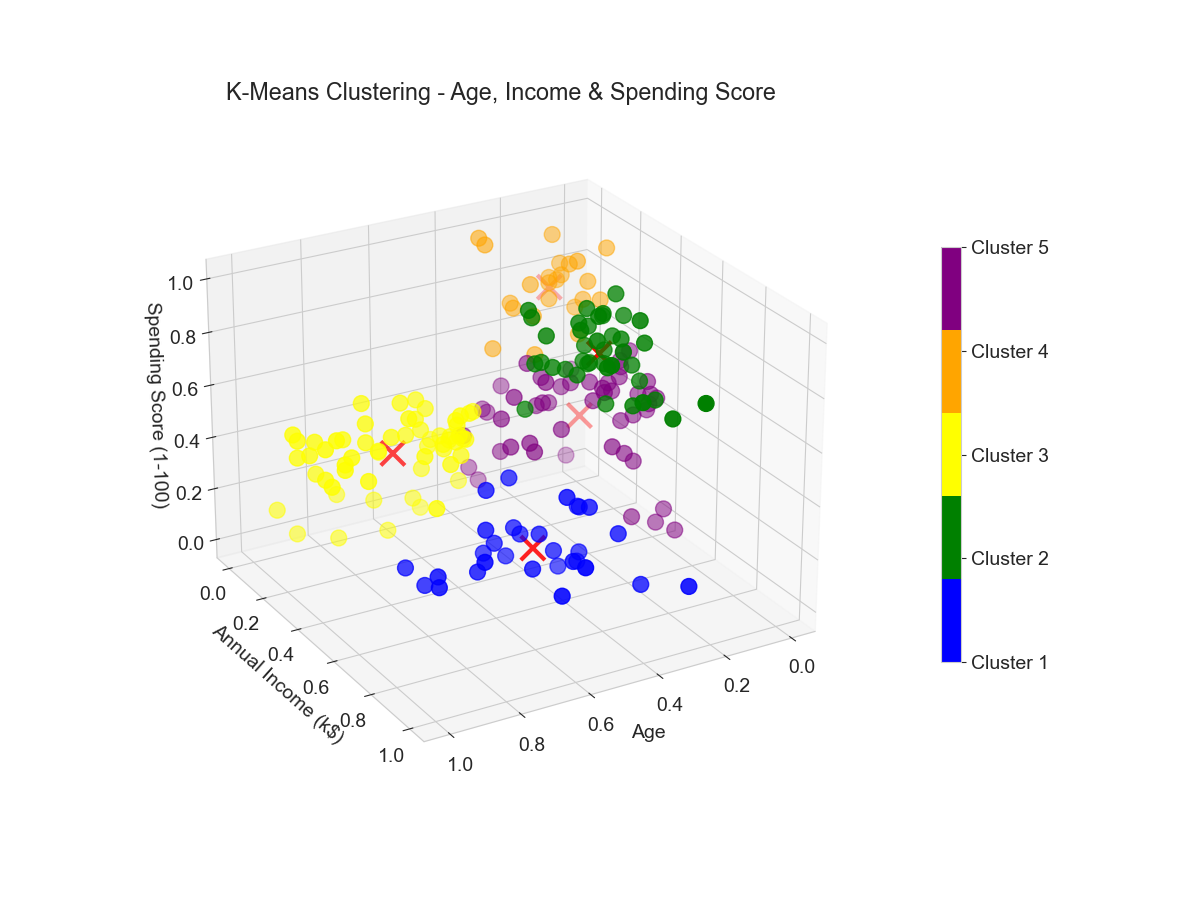

In [14]:
# JupyterLab interactive backend
%matplotlib widget

# Imports
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
from sklearn.cluster import KMeans

# --- KMeans clustering ---
kmeans = KMeans(n_clusters = num_clusters, n_init = 10, random_state = 0)

# Fit to the selected columns
kmeans.fit(df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']])

# Add cluster labels
df['Cluster'] = kmeans.labels_.astype(int)

# --- Plotting ---
sns.set_style('whitegrid')
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

# Custom colormap (one color per cluster)
cluster_colors = ['blue', 'green', 'yellow', 'orange', 'purple'][:num_clusters]
cmap = ListedColormap(cluster_colors)

# 3D scatter plot
scatter = ax.scatter(
    df['Age'],
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c=df['Cluster'],
    s=130,
    cmap=cmap
)

# Colorbar with correct labels.
cbar = fig.colorbar(scatter, ax=ax, pad=0.1, shrink=0.6)
cbar.set_ticks(np.arange(num_clusters))
cbar.set_ticklabels([f'Cluster {i+1}' for i in range(num_clusters)])

# Labels and title.
ax.set_xlabel('Age')
ax.set_ylabel('Annual Income (k$)')
ax.set_zlabel('Spending Score (1-100)')
ax.set_title('K-Means Clustering - Age, Income & Spending Score')

# Plot centroids.
centroids = kmeans.cluster_centers_
ax.scatter(
    centroids[:, 0],
    centroids[:, 1],
    centroids[:, 2],
    marker='x',
    s=300,
    linewidths=3,
    color='red',
    zorder=10
)

# Viewing angle
ax.view_init(elev=25, azim=60)

plt.show()

# Conclusions

Here's how clustering analysis works in this context:

1. Data Collection:
Gather data on customer age, income, and spending habits (e.g., purchase history, average transaction value). 

2. Clustering Algorithm:
Apply a clustering algorithm like K-means to group customers based on similarity in age and income. Other algorithms like hierarchical clustering can also be used. 

3. Segment Definition:
Analyze the resulting clusters to identify distinct groups of customers, such as "young professionals with high income," "families with moderate income," or "retired individuals with lower income". 

4. Targeted Marketing:
Develop marketing campaigns and product recommendations specifically designed for each identified segment. For example: 
High-income, younger customers: Offer premium products and exclusive deals.
Families with moderate income: Focus on value and family-oriented products.
Retirees: Highlight products and services related to health, leisure, and convenience. 

5. Ongoing Optimization:
Continuously monitor the effectiveness of these strategies and adjust the segmentation and marketing efforts as needed. 